In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
cleaned_df = pd.read_csv('../data/cleaned_ecommerce_dataset.csv')


NameError: name 'pd' is not defined

# Exploratory Data Analysis (EDA) & Data Visualization

## Statistical Summary

In [50]:
#stastical summary of the cleaned dataset
cleaned_df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [51]:
#categorical summary of the cleaned dataset
cleaned_df.describe(include="object")

C:\Users\Ifeoluwa\AppData\Local\Temp\ipykernel_10508\1209642488.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cleaned_df.describe(include="object")


,OrderID,Date,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,671,1189,7,655,5,5,1200,4,5
top,ORD200000,2023-08-20,C98474,Printer,533 Main St,Online,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,8,2,181,8,258,250,1,313,259


## Total Revenue Analysis

In [52]:
total_revenue = cleaned_df['TotalPrice'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $1,264,761.96


## Product Performance Analysis

In [53]:
product_sales = cleaned_df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

product_sales

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

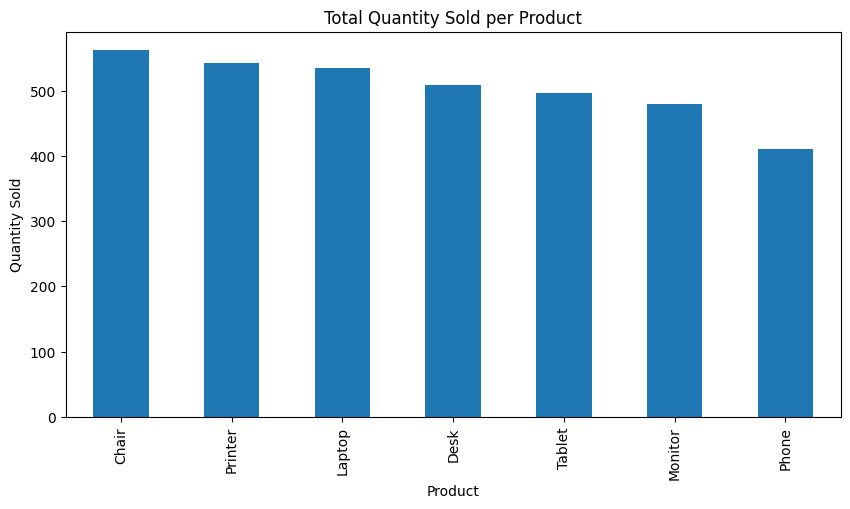

In [54]:
plt.figure(figsize=(10,5))
product_sales.plot(kind='bar')

plt.title('Total Quantity Sold per Product')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

## Revenue by Product

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


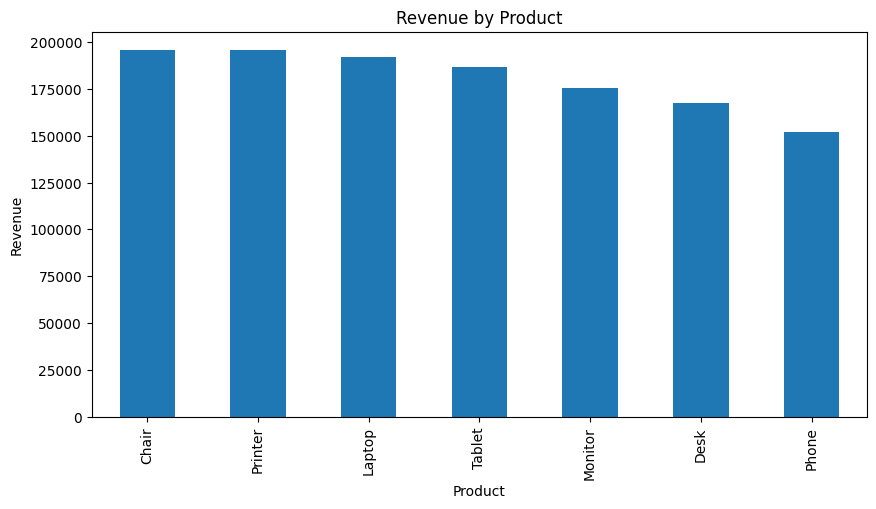

In [55]:
revenue_by_product = cleaned_df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

print(revenue_by_product)
# Visualization
plt.figure(figsize=(10,5))
revenue_by_product.plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

## Payment Method Analysis

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


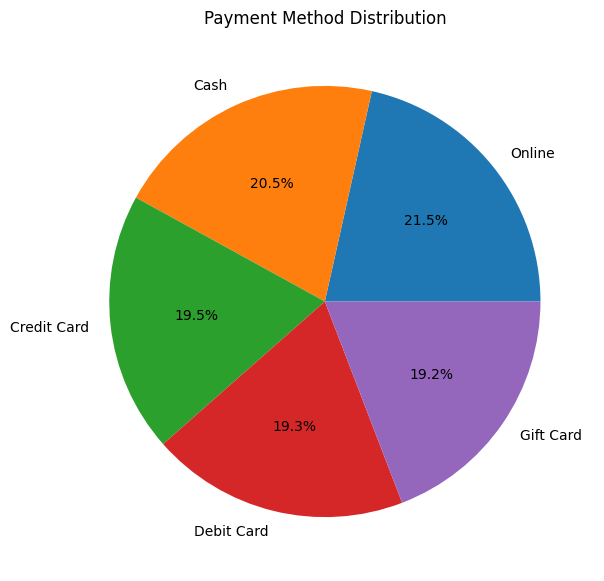

In [56]:
payment_analysis = cleaned_df['PaymentMethod'].value_counts()

print(payment_analysis)

#Visualiztion
plt.figure(figsize=(7,7))

payment_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Payment Method Distribution')

plt.show()

## Order Status Analysis

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


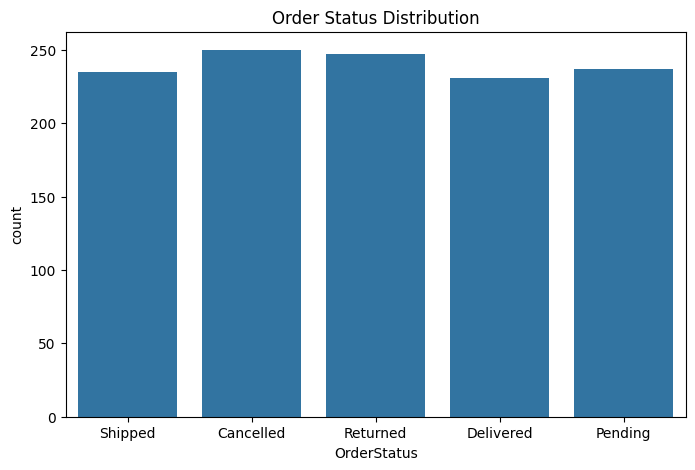

In [57]:
order_status = cleaned_df['OrderStatus'].value_counts()

print(order_status)

## Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=cleaned_df,
    x='OrderStatus'
)

plt.title('Order Status Distribution')
plt.show()

##  Referral Source Analysis

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


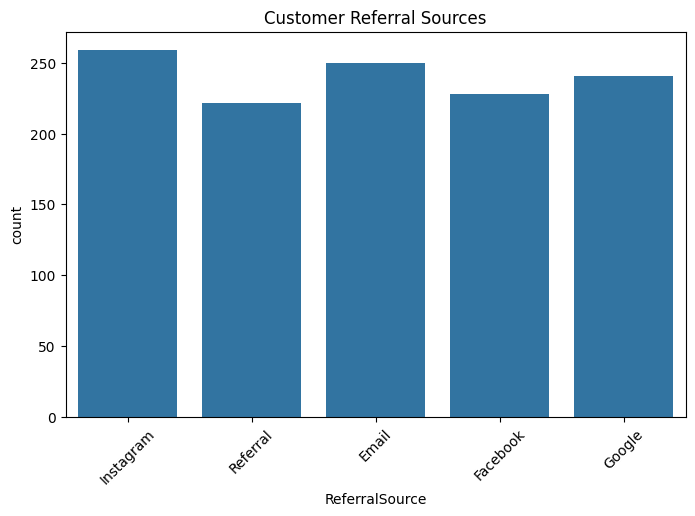

In [58]:
referrals = cleaned_df['ReferralSource'].value_counts()

print(referrals)

#Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=cleaned_df,
    x='ReferralSource'
)

plt.title('Customer Referral Sources')
plt.xticks(rotation=45)

plt.show()

## Monthly Revenue Trend

In [64]:
# # df['Month'] = cleaned_df['Date'].dt.to_period('M')

# # monthly_revenue = cleaned_df.groupby('Month')['TotalPrice'].sum()

# # print(monthly_revenue)

# #Visualization
# plt.figure(figsize=(12,5))

# monthly_revenue.plot()

# plt.title('Monthly Revenue Trend')
# plt.xlabel('Month')
# plt.ylabel('Revenue')

# plt.grid(True)

# plt.show()

## Coupon Usage Analysis

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


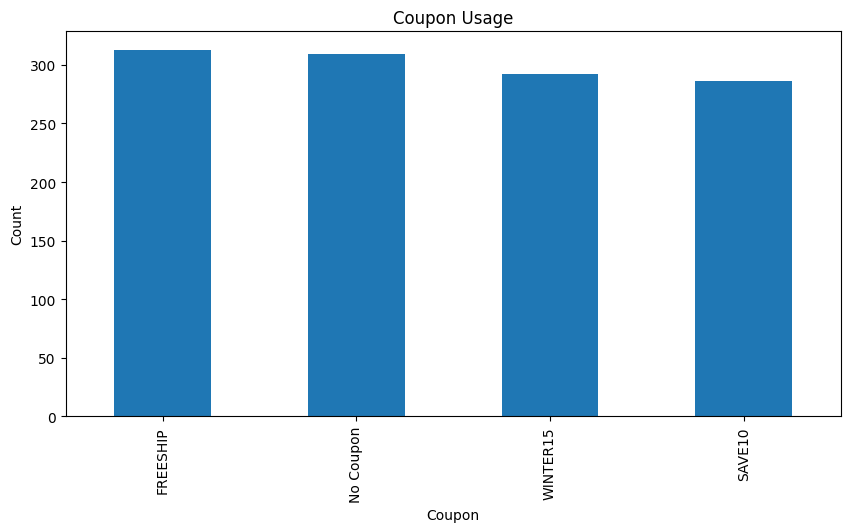

In [65]:
coupon_usage = cleaned_df['CouponCode'].value_counts()

print(coupon_usage.head(10))

#Visualization
plt.figure(figsize=(10,5))

coupon_usage.head(10).plot(kind='bar')

plt.title('Coupon Usage')
plt.xlabel('Coupon')
plt.ylabel('Count')

plt.show()

## Outlier Detection

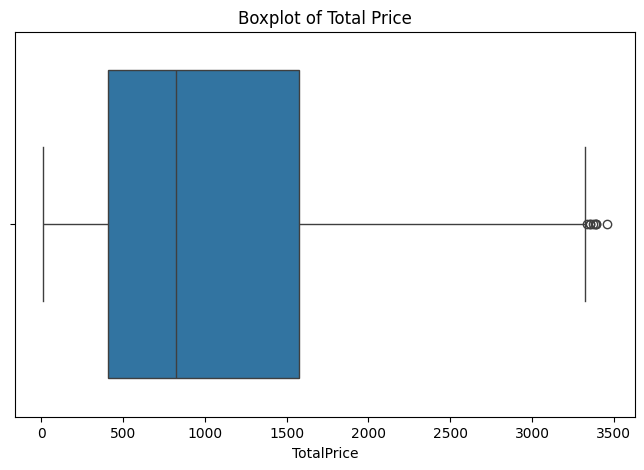

In [66]:
#TotalPrice Outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    x=cleaned_df['TotalPrice']
)

plt.title('Boxplot of Total Price')

plt.show()



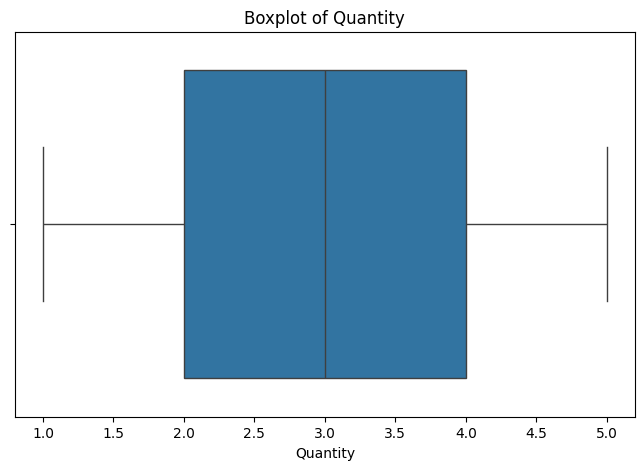

In [67]:
#Quantity Outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    x=cleaned_df['Quantity']
)

plt.title('Boxplot of Quantity')

plt.show()

## Correlation Analysis

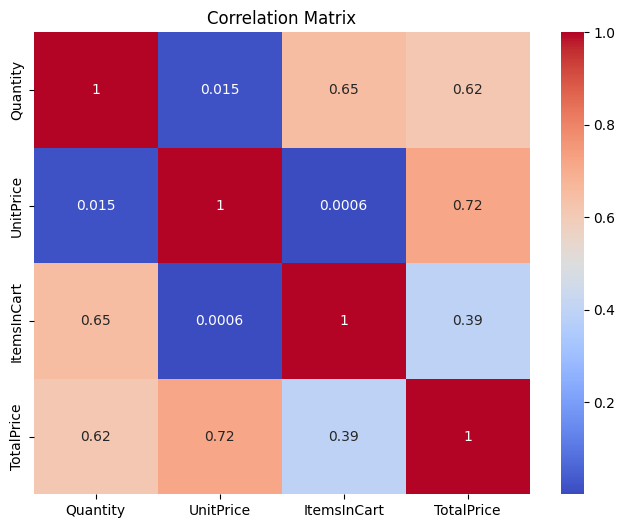

In [69]:
numeric_columns = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice'
]

corr_matrix = cleaned_df[numeric_columns].corr()

corr_matrix
##Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()